In [1]:
!pip install folium contextily geopandas shapely

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 415.4 kB/s eta 0:00:03
   ------------ --------------------------- 0.5/1.7 MB 415.4 kB/s eta 0:00:03
   ------------------ --------------------- 0.8/1.7 MB 515.4 kB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 515.4 kB/s eta 0:00:02
   ------------------------ --------------- 1.0/1.7 MB 556.5 kB/s eta 0:00:02
   ------------------------------------ --- 1.6/1.7 MB 738.7 kB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 789.1 kB/s  0:00:02
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.9 MB ? eta -:--:--
    -------------------------------------

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [13]:
##membaca file csv menggunakan pandas
df = pd.read_csv('../data/Village_LongLat_Approx.csv')
df.head()

,Unnamed: 0,province,district,sub_district,village,approx_long,approx_lat
0,0,ACEH,ACEH SELATAN,BAKONGAN,KEUDE BAKONGAN,97.475542,2.928458
1,1,ACEH,ACEH SELATAN,BAKONGAN,UJUNG MANGKI,97.446373,2.941181
2,2,ACEH,ACEH SELATAN,BAKONGAN,UJUNG PADANG,97.493403,2.941533
3,3,ACEH,ACEH SELATAN,BAKONGAN,KAMPONG DRIEN,97.478184,2.977676
4,4,ACEH,ACEH SELATAN,BAKONGAN,DARUL IKHSAN,97.418400,2.956487


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83322 entries, 0 to 83321
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    83322 non-null  int64  
 1   province      83322 non-null  object 
 2   district      83322 non-null  object 
 3   sub_district  83322 non-null  object 
 4   village       83322 non-null  object 
 5   approx_long   83322 non-null  float64
 6   approx_lat    83322 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 4.5+ MB


In [16]:
df.isnull().sum()

Unnamed: 0      0
province        0
district        0
sub_district    0
village         0
approx_long     0
approx_lat      0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df = df.drop(columns=['Unnamed: 0'])

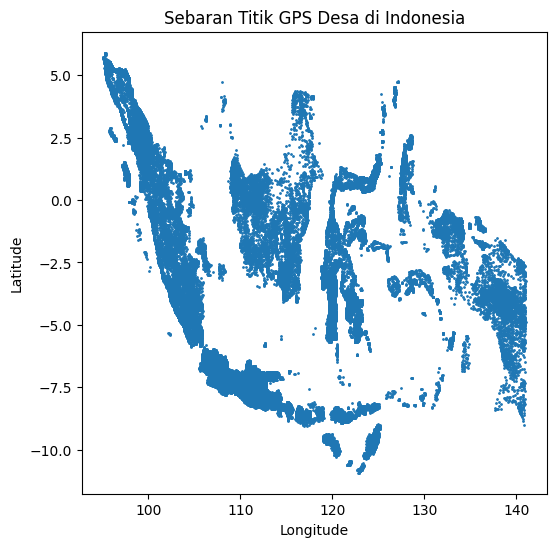

In [19]:
# Scatter Plot Lokasi Desa di Indonesia
plt.figure(figsize=(6,6))
plt.scatter(df['approx_long'], df['approx_lat'], s=1)
plt.title("Sebaran Titik GPS Desa di Indonesia")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [20]:
#visualisasi heatmap gps
m = folium.Map(location=[-2, 118], zoom_start=5)
HeatMap(df[['approx_lat','approx_long']].values).add_to(m)
m

In [21]:
df.columns


Index(['province', 'district', 'sub_district', 'village', 'approx_long',
       'approx_lat'],
      dtype='object')

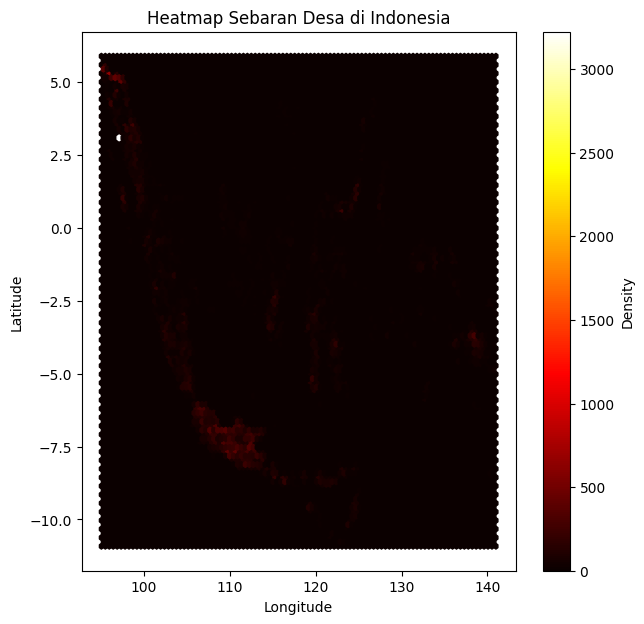

In [22]:
# heatmap densitas desa
plt.figure(figsize=(7,7))
plt.hexbin(df['approx_long'], df['approx_lat'], gridsize=100, cmap='hot')
plt.title('Heatmap Sebaran Desa di Indonesia')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Density')
plt.show()

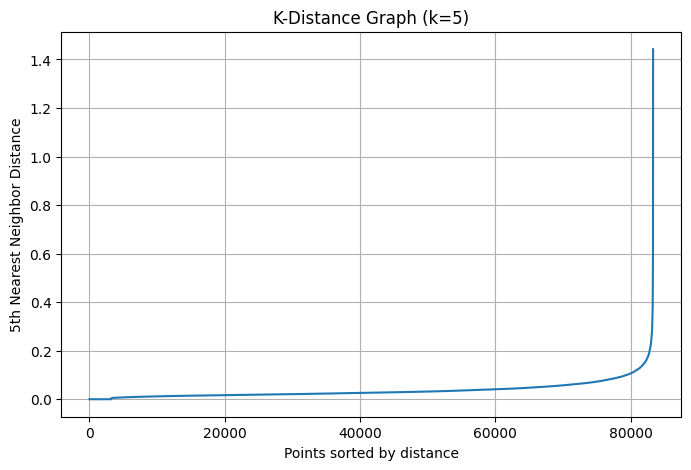

In [23]:
# K-Distance Graph untuk menentukan EPS
coords = df[['approx_lat','approx_long']]

nbrs = NearestNeighbors(n_neighbors=5).fit(coords)
distances, indices = nbrs.kneighbors(coords)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("K-Distance Graph (k=5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

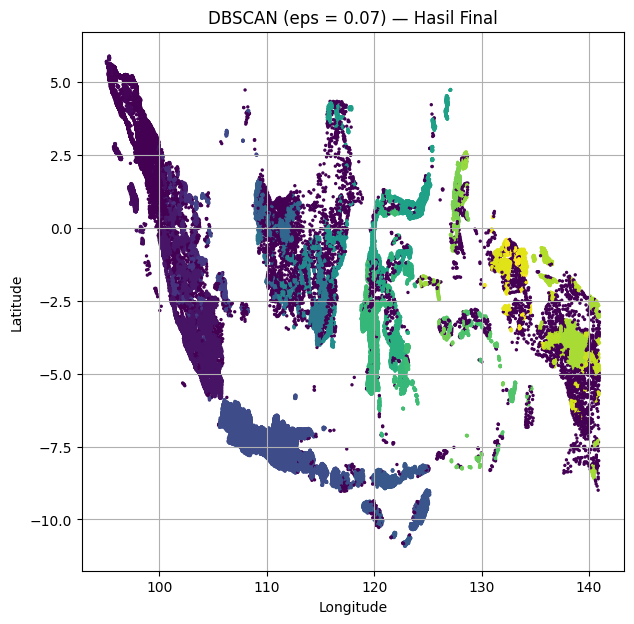

cluster_final
 118    24367
 0       8794
 24      6979
-1       5724
 1       4253
        ...  
 157        3
 241        3
 182        3
 14         2
 12         1
Name: count, Length: 519, dtype: int64

In [24]:
# DBSCAN
# Percobaan DBSCAN eps = 0.05

# model_test = DBSCAN(eps=0.05, min_samples=5)
# labels_test = model_test.fit_predict(coords)
# df['cluster_test'] = labels_test

# plt.figure(figsize=(6,6))
# plt.scatter(df['approx_long'], df['approx_lat'], c=labels_test, s=2)
# plt.title("DBSCAN (eps = 0.05) — Uji Coba")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.grid(True)
# plt.show()

# print(df['cluster_test'].value_counts())

# DBSCAN eps = 0.07
model = DBSCAN(eps=0.07, min_samples=5)
labels = model.fit_predict(coords)

df['cluster_final'] = labels

plt.figure(figsize=(7,7))
plt.scatter(df['approx_long'], df['approx_lat'], c=labels, s=2)
plt.title("DBSCAN (eps = 0.07) — Hasil Final")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

df['cluster_final'].value_counts()

In [25]:
# Hitung Silhouette Score
mask = df['cluster_final'] != -1  # buang noise untuk perhitungan
score = silhouette_score(coords[mask], df['cluster_final'][mask])

print("Silhouette Score:", score)

Silhouette Score: -0.04984441066890462


In [ ]:
#Visualisasi cluster pake PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords_pca = pca.fit_transform(coords)

plt.figure(figsize=(7,6))
plt.scatter(coords_pca[:,0], coords_pca[:,1], c=df['cluster_final'], s=3)
plt.title("Visualisasi Cluster DBSCAN (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

In [ ]:
#  Folium Cluster Map (Persebaran Cluster DBSCAN)

# tentuin warna untuk setiap cluster
import matplotlib.cm as cm
import matplotlib.colors as colors

unique_labels = df['cluster_final'].unique()
cmap = cm.get_cmap('tab20', len(unique_labels))
norm = colors.Normalize(vmin=min(unique_labels), vmax=max(unique_labels))

# Buat map Indonesia
m_cluster = folium.Map(location=[-2, 118], zoom_start=5)

# Tambahkan titik per cluster
for _, row in df.iterrows():
    lbl = row['cluster_final']

    color_hex = colors.to_hex(cmap(norm(lbl)))

    folium.CircleMarker(
        location=[row['approx_lat'], row['approx_long']],
        radius=2,
        color=color_hex,
        fill=True,
        fill_color=color_hex,
        fill_opacity=0.7,
        popup=f"Cluster: {lbl}<br>Desa: {row['village']}"
    ).add_to(m_cluster)

m_cluster

C:\Users\MyLaptop\AppData\Local\Temp\ipykernel_20184\4083581734.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_labels))
